In [7]:
# Naive Model for Voltage Prediction

import os
import sys
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define functions for the naive model
def plot_comparison(actual, predicted, title, xlabel, ylabel, ax):
    """
    Plot actual vs predicted values.
    
    Args:
        actual: List of actual values
        predicted: List of predicted values
        title: Plot title
        xlabel: X-axis label
        ylabel: Y-axis label
        ax: Matplotlib axis object
    """
    ax.plot(actual, label='Actual', marker='o', markersize=4, linestyle='-', alpha=0.7)
    ax.plot(predicted, label='Predicted (Naive)', marker='x', markersize=4, linestyle='--', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Calculate and display MAE on the plot
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    ax.text(0.05, 0.95, f'MAE: {mae:.6f}\nRMSE: {rmse:.6f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

def run_naive_model(builder, num_timesteps=100, plot_results=True):
    """
    Implements a naive model for voltage prediction that simply uses 
    the last observed values as predictions for the next time step.
    
    Args:
        builder: PandaPowerFlowBuilder instance
        num_timesteps: Number of timesteps to analyze
        plot_results: Whether to plot voltage prediction results
    
    Returns:
        Dictionary with error metrics
    """
    # Ensure we have at least 2 timesteps for prediction
    if num_timesteps < 2:
        raise ValueError("Need at least 2 timesteps for prediction")
    
    # Make sure we don't exceed the available timestamps in the builder
    num_timesteps = min(num_timesteps, len(builder.timestamps))
    
    # Create empty lists to store actual and predicted values
    actual_vm = {}  # Dictionary to store actual voltage magnitudes for each bus
    actual_va = {}  # Dictionary to store actual voltage angles for each bus
    pred_vm = {}    # Dictionary to store predicted voltage magnitudes
    pred_va = {}    # Dictionary to store predicted voltage angles
    
    # Get the first sample to identify buses
    first_sample = builder.run(builder.timestamps[0])
    bus_ids = list(first_sample.res_bus.index)
    
    # Initialize dictionaries
    for bus_id in bus_ids:
        actual_vm[bus_id] = []
        actual_va[bus_id] = []
        pred_vm[bus_id] = []
        pred_va[bus_id] = []
    
    # Get actual values for all timesteps
    print(f"Processing {num_timesteps} timesteps...")
    for t in range(num_timesteps):
        # Run power flow for current timestep
        sample = builder.run(builder.timestamps[t])
        
        # Store actual values for each bus
        for bus_id, bus in sample.res_bus.iterrows():
            actual_vm[bus_id].append(float(bus['vm_pu']))
            actual_va[bus_id].append(float(bus['va_degree']))
    
    # Generate predictions (t+1 = t)
    for bus_id in bus_ids:
        # The prediction for each timestep is the value from the previous timestep
        # For the first timestep, we have no prediction
        pred_vm[bus_id] = actual_vm[bus_id][:-1]  # Predictions stop at t-1
        pred_va[bus_id] = actual_va[bus_id][:-1]  # Predictions stop at t-1
    
    # Calculate errors for each bus
    vm_mae_per_bus = {}
    va_mae_per_bus = {}
    vm_rmse_per_bus = {}
    va_rmse_per_bus = {}
    
    for bus_id in bus_ids:
        # Actual values start from t=1 (since we're predicting t from t-1)
        vm_actual = actual_vm[bus_id][1:]
        va_actual = actual_va[bus_id][1:]
        
        # Calculate metrics
        vm_mae_per_bus[bus_id] = mean_absolute_error(vm_actual, pred_vm[bus_id])
        va_mae_per_bus[bus_id] = mean_absolute_error(va_actual, pred_va[bus_id])
        vm_rmse_per_bus[bus_id] = np.sqrt(mean_squared_error(vm_actual, pred_vm[bus_id]))
        va_rmse_per_bus[bus_id] = np.sqrt(mean_squared_error(va_actual, pred_va[bus_id]))
    
    # Calculate overall metrics (average across all buses)
    avg_vm_mae = np.mean(list(vm_mae_per_bus.values()))
    avg_va_mae = np.mean(list(va_mae_per_bus.values()))
    avg_vm_rmse = np.mean(list(vm_rmse_per_bus.values()))
    avg_va_rmse = np.mean(list(va_rmse_per_bus.values()))
    
    print("\nNaive Model Results:")
    print(f"Average Voltage Magnitude MAE: {avg_vm_mae:.6f} pu")
    print(f"Average Voltage Magnitude RMSE: {avg_vm_rmse:.6f} pu")
    print(f"Average Voltage Angle MAE: {avg_va_mae:.6f} degrees")
    print(f"Average Voltage Angle RMSE: {avg_va_rmse:.6f} degrees")
    
    # Find best and worst performing buses
    best_vm_bus = min(vm_mae_per_bus.items(), key=lambda x: x[1])[0]
    worst_vm_bus = max(vm_mae_per_bus.items(), key=lambda x: x[1])[0]
    best_va_bus = min(va_mae_per_bus.items(), key=lambda x: x[1])[0]
    worst_va_bus = max(va_mae_per_bus.items(), key=lambda x: x[1])[0]
    
    print("\nBest performing buses:")
    print(f"  Best Voltage Magnitude: Bus {best_vm_bus} (MAE: {vm_mae_per_bus[best_vm_bus]:.6f} pu)")
    print(f"  Best Voltage Angle: Bus {best_va_bus} (MAE: {va_mae_per_bus[best_va_bus]:.6f} degrees)")
    
    print("\nWorst performing buses:")
    print(f"  Worst Voltage Magnitude: Bus {worst_vm_bus} (MAE: {vm_mae_per_bus[worst_vm_bus]:.6f} pu)")
    print(f"  Worst Voltage Angle: Bus {worst_va_bus} (MAE: {va_mae_per_bus[worst_va_bus]:.6f} degrees)")
    
    # Plot results for a few selected buses if requested
    if plot_results:
        # Plot best and worst buses for voltage magnitude
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Plot best VM bus
        plot_comparison(
            actual_vm[best_vm_bus][1:],  # Actual values starting from t=1
            pred_vm[best_vm_bus],        # Predicted values
            f"Best Voltage Magnitude: Bus {best_vm_bus}",
            "Timestep",
            "Voltage (pu)",
            axes[0, 0]
        )
        
        # Plot worst VM bus
        plot_comparison(
            actual_vm[worst_vm_bus][1:],  # Actual values starting from t=1
            pred_vm[worst_vm_bus],        # Predicted values
            f"Worst Voltage Magnitude: Bus {worst_vm_bus}",
            "Timestep",
            "Voltage (pu)",
            axes[0, 1]
        )
        
        # Plot best VA bus
        plot_comparison(
            actual_va[best_va_bus][1:],  # Actual values starting from t=1
            pred_va[best_va_bus],        # Predicted values
            f"Best Voltage Angle: Bus {best_va_bus}",
            "Timestep",
            "Angle (degrees)",
            axes[1, 0]
        )
        
        # Plot worst VA bus
        plot_comparison(
            actual_va[worst_va_bus][1:],  # Actual values starting from t=1
            pred_va[worst_va_bus],        # Predicted values
            f"Worst Voltage Angle: Bus {worst_va_bus}",
            "Timestep",
            "Angle (degrees)",
            axes[1, 1]
        )
        
        plt.tight_layout()
        plt.show()
        
        # Plot error distribution across all buses
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # VM error distribution
        axes[0].hist(list(vm_mae_per_bus.values()), bins=20)
        axes[0].set_title('Voltage Magnitude MAE Distribution')
        axes[0].set_xlabel('MAE (pu)')
        axes[0].set_ylabel('Number of Buses')
        axes[0].grid(True, alpha=0.3)
        
        # VA error distribution
        axes[1].hist(list(va_mae_per_bus.values()), bins=20)
        axes[1].set_title('Voltage Angle MAE Distribution')
        axes[1].set_xlabel('MAE (degrees)')
        axes[1].set_ylabel('Number of Buses')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    # Return results
    return {
        'avg_vm_mae': avg_vm_mae,
        'avg_va_mae': avg_va_mae,
        'avg_vm_rmse': avg_vm_rmse,
        'avg_va_rmse': avg_va_rmse,
        'vm_mae_per_bus': vm_mae_per_bus,
        'va_mae_per_bus': va_mae_per_bus,
        'vm_rmse_per_bus': vm_rmse_per_bus,
        'va_rmse_per_bus': va_rmse_per_bus,
        'best_vm_bus': best_vm_bus,
        'worst_vm_bus': worst_vm_bus,
        'best_va_bus': best_va_bus,
        'worst_va_bus': worst_va_bus,
        'actual_vm': actual_vm,
        'actual_va': actual_va,
        'pred_vm': pred_vm,
        'pred_va': pred_va
    }

import sys
import os
import pandas as pd
import pickle

# Get the absolute path of the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

# Define the directory and file path
save_dir = "../data/parsed/"
load_path = os.path.join(save_dir, "builder.pkl")

# Load the builder object
with open(load_path, "rb") as f:
    builder = pickle.load(f)

# Display basic info about the builder
print(f"Builder loaded successfully with {len(builder.timestamps)} total timesteps")
print(f"First timestamp: {builder.timestamps[0]}")
print(f"Last timestamp: {builder.timestamps[-1]}")

Builder loaded successfully with 8760 total timesteps
First timestamp: 2024-01-01 00:00:00
Last timestamp: 2024-12-31 23:00:00



Network summary:
- Number of buses: 118
- Number of lines: 177
- Number of transformers: 9
- Number of generators: 321
- Number of loads: 91

Running naive model for 100 timesteps...
Processing 100 timesteps...

Naive Model Results:
Average Voltage Magnitude MAE: 0.002112 pu
Average Voltage Magnitude RMSE: 0.003063 pu
Average Voltage Angle MAE: 0.402485 degrees
Average Voltage Angle RMSE: 0.547387 degrees

Best performing buses:
  Best Voltage Magnitude: Bus 11 (MAE: 0.000000 pu)
  Best Voltage Angle: Bus 68 (MAE: 0.000000 degrees)

Worst performing buses:
  Worst Voltage Magnitude: Bus 94 (MAE: 0.008737 pu)
  Worst Voltage Angle: Bus 28 (MAE: 1.423706 degrees)


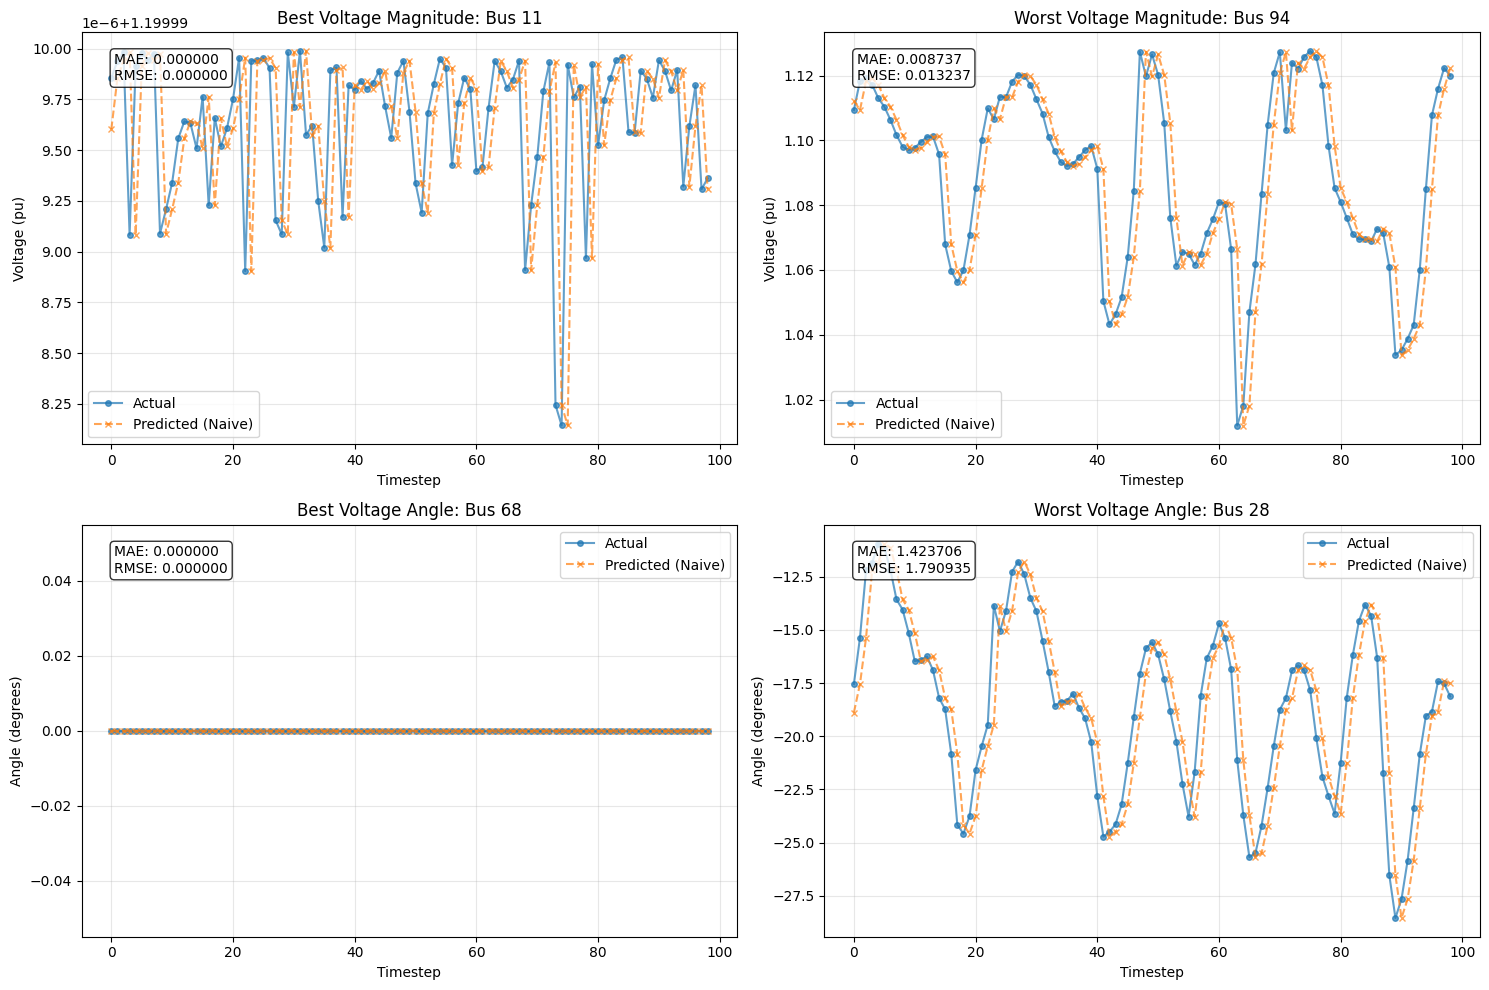

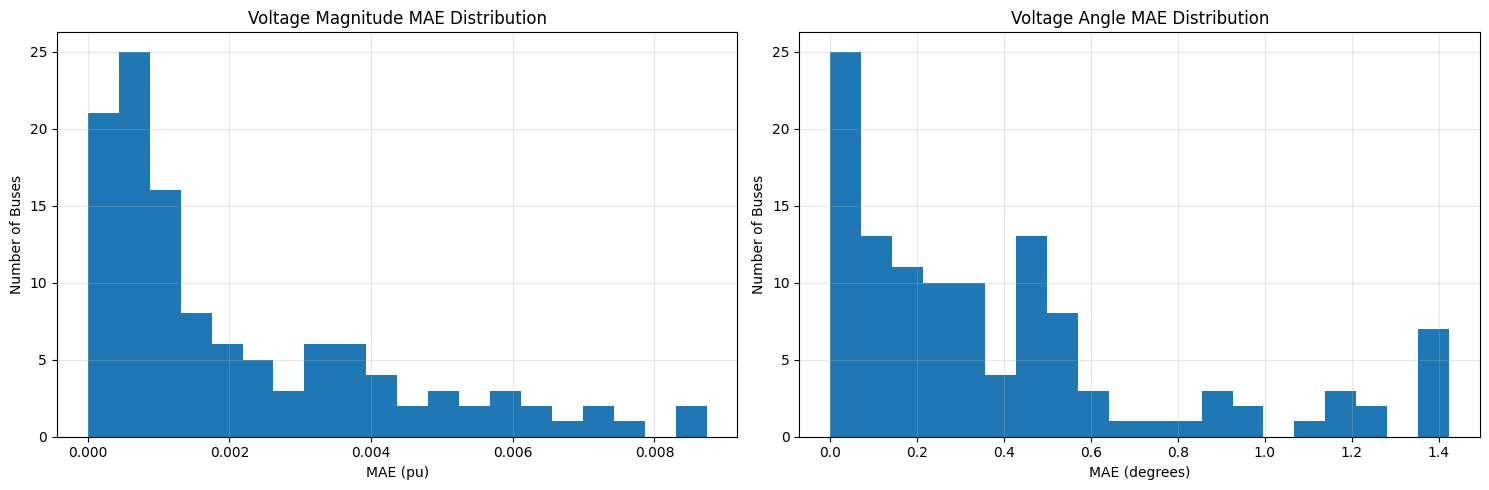


Saving results to ../results/naive_model_results.pkl

Summary statistics for per-bus errors:
             vm_mae      va_mae       vm_rmse     va_rmse
count  1.180000e+02  118.000000  1.180000e+02  118.000000
mean   2.112204e-03    0.402485  3.062710e-03    0.547387
std    2.134434e-03    0.391374  3.165673e-03    0.512438
min    2.962824e-07    0.000000  4.545706e-07    0.000000
25%    5.660829e-04    0.084732  8.721839e-04    0.129786
50%    1.111032e-03    0.283565  1.590005e-03    0.386071
75%    3.325009e-03    0.516156  4.976307e-03    0.679984
max    8.736793e-03    1.423706  1.323684e-02    1.871368

Top 5 buses with highest voltage magnitude errors:
      vm_mae    va_mae   vm_rmse   va_rmse
94  0.008737  0.536726  0.013237  0.802710
83  0.008581  0.568291  0.013214  0.840484
82  0.007697  0.612494  0.012372  0.902635
85  0.007173  0.424073  0.010851  0.628375
84  0.007153  0.486189  0.010943  0.718681

Top 5 buses with highest voltage angle errors:
       vm_mae    va_mae   

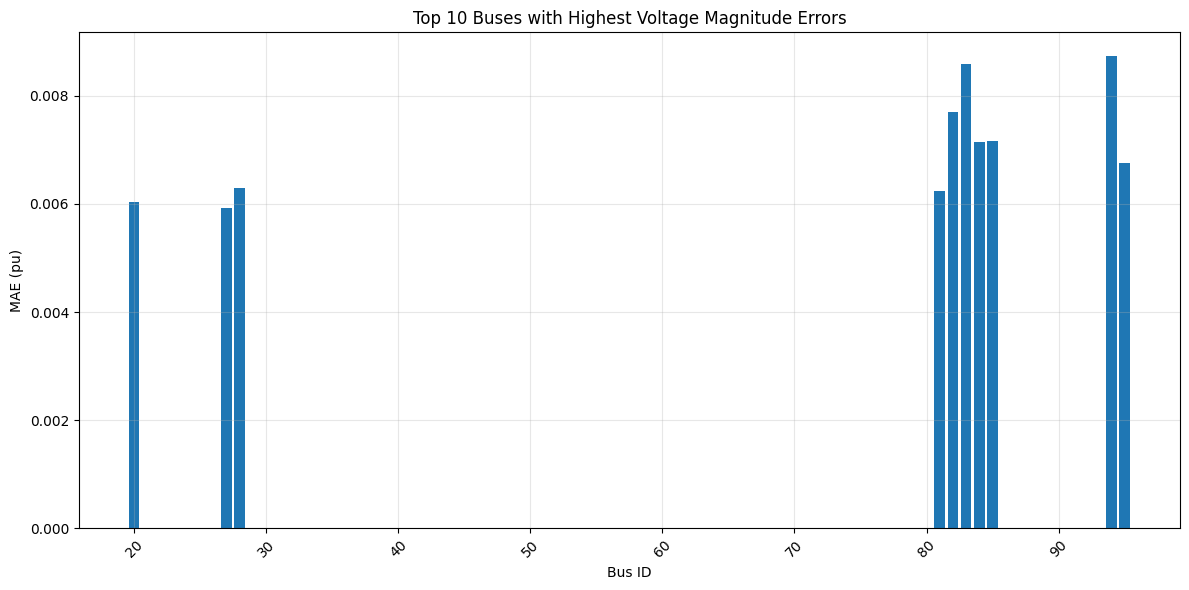

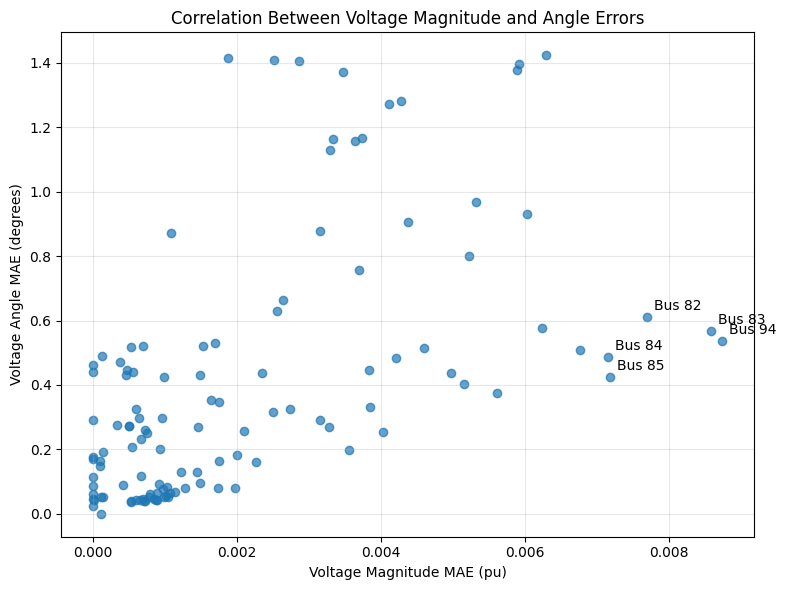


Naive model analysis complete!


In [8]:
# Get a sample to check what's in the network
sample = builder.run(builder.timestamps[0])
print("\nNetwork summary:")
print(f"- Number of buses: {len(sample.res_bus)}")
print(f"- Number of lines: {len(sample.res_line)}")
print(f"- Number of transformers: {len(sample.res_trafo)}")
print(f"- Number of generators: {len(sample.res_gen)}")
print(f"- Number of loads: {len(sample.res_load)}")

# Run the naive model for a smaller number of timesteps (for testing)
print("\nRunning naive model for 100 timesteps...")
results = run_naive_model(builder, num_timesteps=100, plot_results=True)

# Save the results (optional)
results_dir = "../results"
os.makedirs(results_dir, exist_ok=True)
results_path = os.path.join(results_dir, "naive_model_results.pkl")

print(f"\nSaving results to {results_path}")
with open(results_path, "wb") as f:
    pickle.dump(results, f)

# Create a pandas DataFrame for the per-bus results for better analysis
bus_results = pd.DataFrame({
    'vm_mae': pd.Series(results['vm_mae_per_bus']),
    'va_mae': pd.Series(results['va_mae_per_bus']),
    'vm_rmse': pd.Series(results['vm_rmse_per_bus']),
    'va_rmse': pd.Series(results['va_rmse_per_bus'])
})

print("\nSummary statistics for per-bus errors:")
print(bus_results.describe())

# Identify buses with unusual behavior
print("\nTop 5 buses with highest voltage magnitude errors:")
print(bus_results.nlargest(5, 'vm_mae'))

print("\nTop 5 buses with highest voltage angle errors:")
print(bus_results.nlargest(5, 'va_mae'))

# Visualize the most interesting bus errors
plt.figure(figsize=(12, 6))
top_vm_buses = bus_results.nlargest(10, 'vm_mae').index
plt.bar(top_vm_buses, [bus_results.loc[bus, 'vm_mae'] for bus in top_vm_buses])
plt.title('Top 10 Buses with Highest Voltage Magnitude Errors')
plt.xlabel('Bus ID')
plt.ylabel('MAE (pu)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation between voltage magnitude and angle errors
plt.figure(figsize=(8, 6))
plt.scatter(bus_results['vm_mae'], bus_results['va_mae'], alpha=0.7)
plt.title('Correlation Between Voltage Magnitude and Angle Errors')
plt.xlabel('Voltage Magnitude MAE (pu)')
plt.ylabel('Voltage Angle MAE (degrees)')
plt.grid(True, alpha=0.3)

# Add bus IDs for the top 5 worst performers
for bus in bus_results.nlargest(5, 'vm_mae').index:
    plt.annotate(f"Bus {bus}", 
                (bus_results.loc[bus, 'vm_mae'], bus_results.loc[bus, 'va_mae']),
                xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("\nNaive model analysis complete!")

In [9]:
# Day-Ahead Prediction Model

import os
import sys
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import traceback

def plot_comparison(actual, predicted, title, xlabel, ylabel, ax):
    """
    Plot actual vs predicted values.
    
    Args:
        actual: List of actual values
        predicted: List of predicted values
        title: Plot title
        xlabel: X-axis label
        ylabel: Y-axis label
        ax: Matplotlib axis object
    """
    ax.plot(actual, label='Actual', marker='o', markersize=4, linestyle='-', alpha=0.7)
    ax.plot(predicted, label='Predicted', marker='x', markersize=4, linestyle='--', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Calculate and display MAE on the plot
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    ax.text(0.05, 0.95, f'MAE: {mae:.6f}\nRMSE: {rmse:.6f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

def run_day_ahead_model(builder, num_days=30, horizon=24, stride=24, plot_results=True):
    """
    Implements a day-ahead prediction model where we predict 24 hours into the future
    with a 24-hour stride (non-overlapping windows).
    
    Args:
        builder: PandaPowerFlowBuilder instance
        num_days: Number of days to analyze
        horizon: Number of hours to predict ahead (default is 24 hours)
        stride: Number of hours to move forward for each prediction (default is 24 hours)
        plot_results: Whether to plot prediction results
    
    Returns:
        Dictionary with error metrics
    """
    # Calculate total timesteps needed
    # We need an initial day + num_days for prediction
    total_timesteps = (num_days + 1) * 24
    
    # Make sure we don't exceed the available timestamps in the builder
    total_timesteps = min(total_timesteps, len(builder.timestamps))
    num_days = (total_timesteps - 24) // stride  # Adjust num_days based on available data
    
    print(f"Using {total_timesteps} total timesteps, equivalent to {num_days+1} days")
    
    # Create empty lists to store actual and predicted values
    actual_vm = {}  # Dictionary to store actual voltage magnitudes for each bus
    actual_va = {}  # Dictionary to store actual voltage angles for each bus
    pred_vm = {}    # Dictionary to store predicted voltage magnitudes
    pred_va = {}    # Dictionary to store predicted voltage angles
    
    # Get the first sample to identify buses
    first_sample = builder.run(builder.timestamps[0])
    bus_ids = list(first_sample.res_bus.index)
    
    # Initialize dictionaries
    for bus_id in bus_ids:
        actual_vm[bus_id] = []
        actual_va[bus_id] = []
        pred_vm[bus_id] = []
        pred_va[bus_id] = []
    
    # Get all actual values
    print(f"Processing {total_timesteps} timesteps...")
    all_timestep_data = []
    
    for t in range(total_timesteps):
        # Run power flow for current timestep
        sample = builder.run(builder.timestamps[t])
        
        # Store the data for this timestep
        timestep_data = {}
        for bus_id, bus in sample.res_bus.iterrows():
            timestep_data[bus_id] = {
                'vm_pu': float(bus['vm_pu']),
                'va_degree': float(bus['va_degree'])
            }
        
        all_timestep_data.append(timestep_data)
    
    # Implement day-ahead prediction with stride
    # Initial pattern of data is presumed to be hourly
    prediction_points = []
    
    for day in range(num_days):
        start_idx = day * stride  # Start of current day
        target_idx = start_idx + horizon  # 24 hours later (next day same hour)
        
        # For each hour in the horizon
        for h in range(horizon):
            prediction_points.append((start_idx + h, target_idx + h))
    
    # Generate predictions and store actual values for comparison
    print(f"Generating {len(prediction_points)} predictions...")
    
    for source_idx, target_idx in prediction_points:
        source_data = all_timestep_data[source_idx]
        target_data = all_timestep_data[target_idx]
        
        for bus_id in bus_ids:
            # Store the actual target value for this prediction
            actual_vm[bus_id].append(target_data[bus_id]['vm_pu'])
            actual_va[bus_id].append(target_data[bus_id]['va_degree'])
            
            # Use the source value as the prediction (naive day-ahead model)
            pred_vm[bus_id].append(source_data[bus_id]['vm_pu'])
            pred_va[bus_id].append(source_data[bus_id]['va_degree'])
    
    # Calculate errors for each bus
    vm_mae_per_bus = {}
    va_mae_per_bus = {}
    vm_rmse_per_bus = {}
    va_rmse_per_bus = {}
    
    for bus_id in bus_ids:
        vm_mae_per_bus[bus_id] = mean_absolute_error(actual_vm[bus_id], pred_vm[bus_id])
        va_mae_per_bus[bus_id] = mean_absolute_error(actual_va[bus_id], pred_va[bus_id])
        vm_rmse_per_bus[bus_id] = np.sqrt(mean_squared_error(actual_vm[bus_id], pred_vm[bus_id]))
        va_rmse_per_bus[bus_id] = np.sqrt(mean_squared_error(actual_va[bus_id], pred_va[bus_id]))
    
    # Calculate overall metrics (average across all buses)
    avg_vm_mae = np.mean(list(vm_mae_per_bus.values()))
    avg_va_mae = np.mean(list(va_mae_per_bus.values()))
    avg_vm_rmse = np.mean(list(vm_rmse_per_bus.values()))
    avg_va_rmse = np.mean(list(va_rmse_per_bus.values()))
    
    print("\nDay-Ahead Model Results:")
    print(f"Average Voltage Magnitude MAE: {avg_vm_mae:.6f} pu")
    print(f"Average Voltage Magnitude RMSE: {avg_vm_rmse:.6f} pu")
    print(f"Average Voltage Angle MAE: {avg_va_mae:.6f} degrees")
    print(f"Average Voltage Angle RMSE: {avg_va_rmse:.6f} degrees")
    
    # Find best and worst performing buses
    best_vm_bus = min(vm_mae_per_bus.items(), key=lambda x: x[1])[0]
    worst_vm_bus = max(vm_mae_per_bus.items(), key=lambda x: x[1])[0]
    best_va_bus = min(va_mae_per_bus.items(), key=lambda x: x[1])[0]
    worst_va_bus = max(va_mae_per_bus.items(), key=lambda x: x[1])[0]
    
    print("\nBest performing buses:")
    print(f"  Best Voltage Magnitude: Bus {best_vm_bus} (MAE: {vm_mae_per_bus[best_vm_bus]:.6f} pu)")
    print(f"  Best Voltage Angle: Bus {best_va_bus} (MAE: {va_mae_per_bus[best_va_bus]:.6f} degrees)")
    
    print("\nWorst performing buses:")
    print(f"  Worst Voltage Magnitude: Bus {worst_vm_bus} (MAE: {vm_mae_per_bus[worst_vm_bus]:.6f} pu)")
    print(f"  Worst Voltage Angle: Bus {worst_va_bus} (MAE: {va_mae_per_bus[worst_va_bus]:.6f} degrees)")
    
    # Plot results for a few selected buses if requested
    if plot_results:
        # Plot best and worst buses for voltage magnitude
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # For better visualization, plot a subset of the predictions (first 7 days)
        max_points = min(7 * horizon, len(pred_vm[best_vm_bus]))
        
        # Plot best VM bus
        plot_comparison(
            actual_vm[best_vm_bus][:max_points],
            pred_vm[best_vm_bus][:max_points],
            f"Best Voltage Magnitude: Bus {best_vm_bus}",
            "Prediction Index (hour)",
            "Voltage (pu)",
            axes[0, 0]
        )
        
        # Plot worst VM bus
        plot_comparison(
            actual_vm[worst_vm_bus][:max_points],
            pred_vm[worst_vm_bus][:max_points],
            f"Worst Voltage Magnitude: Bus {worst_vm_bus}",
            "Prediction Index (hour)",
            "Voltage (pu)",
            axes[0, 1]
        )
        
        # Plot best VA bus
        plot_comparison(
            actual_va[best_va_bus][:max_points],
            pred_va[best_va_bus][:max_points],
            f"Best Voltage Angle: Bus {best_va_bus}",
            "Prediction Index (hour)",
            "Angle (degrees)",
            axes[1, 0]
        )
        
        # Plot worst VA bus
        plot_comparison(
            actual_va[worst_va_bus][:max_points],
            pred_va[worst_va_bus][:max_points],
            f"Worst Voltage Angle: Bus {worst_va_bus}",
            "Prediction Index (hour)",
            "Angle (degrees)",
            axes[1, 1]
        )
        
        plt.tight_layout()
        plt.show()
        
        # Plot error distribution across all buses
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # VM error distribution
        axes[0].hist(list(vm_mae_per_bus.values()), bins=20)
        axes[0].set_title('Voltage Magnitude MAE Distribution')
        axes[0].set_xlabel('MAE (pu)')
        axes[0].set_ylabel('Number of Buses')
        axes[0].grid(True, alpha=0.3)
        
        # VA error distribution
        axes[1].hist(list(va_mae_per_bus.values()), bins=20)
        axes[1].set_title('Voltage Angle MAE Distribution')
        axes[1].set_xlabel('MAE (degrees)')
        axes[1].set_ylabel('Number of Buses')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Create a heatmap of prediction errors over time for the worst bus
        if len(prediction_points) >= horizon:  # Only if we have enough data points
            # Reshape predictions for the worst VM bus into days x hours
            days = min(num_days, len(pred_vm[worst_vm_bus]) // horizon)
            vm_errors = np.zeros((days, horizon))
            
            for day in range(days):
                for hour in range(horizon):
                    idx = day * horizon + hour
                    if idx < len(pred_vm[worst_vm_bus]):
                        # Calculate absolute error for this point
                        vm_errors[day, hour] = abs(actual_vm[worst_vm_bus][idx] - pred_vm[worst_vm_bus][idx])
            
            # Plot heatmap
            plt.figure(figsize=(12, 8))
            plt.imshow(vm_errors, aspect='auto', cmap='viridis')
            plt.colorbar(label='Absolute Error (pu)')
            plt.title(f'Voltage Magnitude Prediction Errors Over Time (Bus {worst_vm_bus})')
            plt.xlabel('Hour of Day')
            plt.ylabel('Day')
            plt.xticks(range(0, 24, 2))
            plt.yticks(range(days))
            plt.grid(False)
            plt.tight_layout()
            plt.show()
    
    # Return results
    return {
        'avg_vm_mae': avg_vm_mae,
        'avg_va_mae': avg_va_mae,
        'avg_vm_rmse': avg_vm_rmse,
        'avg_va_rmse': avg_va_rmse,
        'vm_mae_per_bus': vm_mae_per_bus,
        'va_mae_per_bus': va_mae_per_bus,
        'vm_rmse_per_bus': vm_rmse_per_bus,
        'va_rmse_per_bus': va_rmse_per_bus,
        'best_vm_bus': best_vm_bus,
        'worst_vm_bus': worst_vm_bus,
        'best_va_bus': best_va_bus,
        'worst_va_bus': worst_va_bus,
        'actual_vm': actual_vm,
        'actual_va': actual_va,
        'pred_vm': pred_vm,
        'pred_va': pred_va,
        'prediction_points': prediction_points
    }

Loading the builder object...

Running day-ahead model...
Using 264 total timesteps, equivalent to 11 days
Processing 264 timesteps...
Generating 240 predictions...

Day-Ahead Model Results:
Average Voltage Magnitude MAE: 0.003935 pu
Average Voltage Magnitude RMSE: 0.005621 pu
Average Voltage Angle MAE: 0.796508 degrees
Average Voltage Angle RMSE: 1.096796 degrees

Best performing buses:
  Best Voltage Magnitude: Bus 11 (MAE: 0.000000 pu)
  Best Voltage Angle: Bus 68 (MAE: 0.000000 degrees)

Worst performing buses:
  Worst Voltage Magnitude: Bus 73 (MAE: 0.015958 pu)
  Worst Voltage Angle: Bus 28 (MAE: 2.625508 degrees)


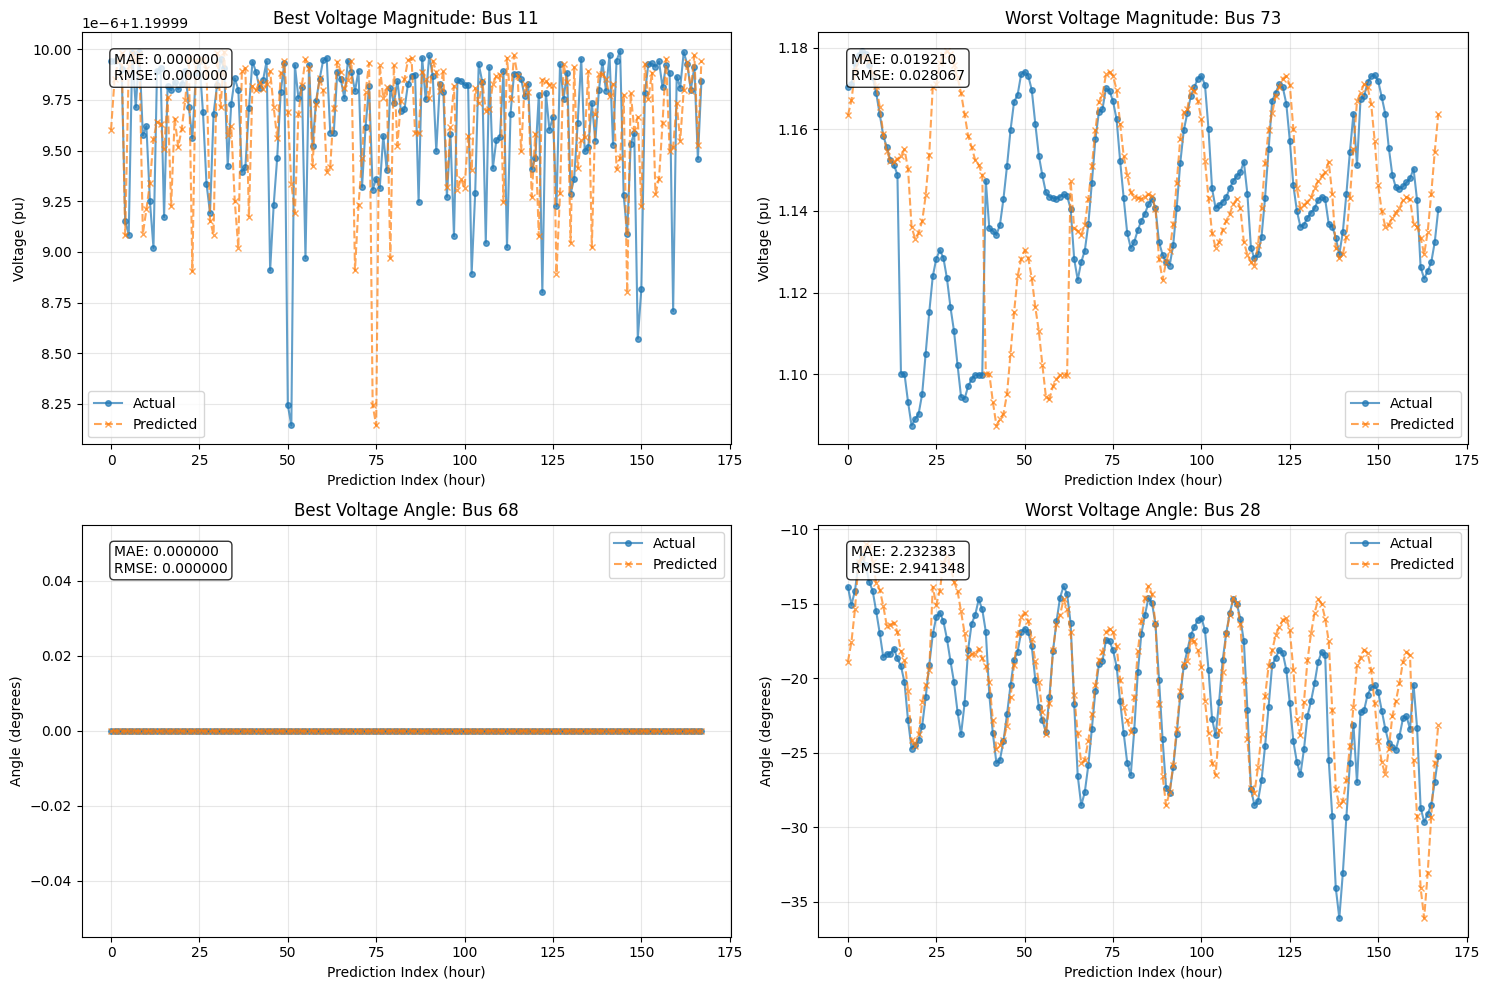

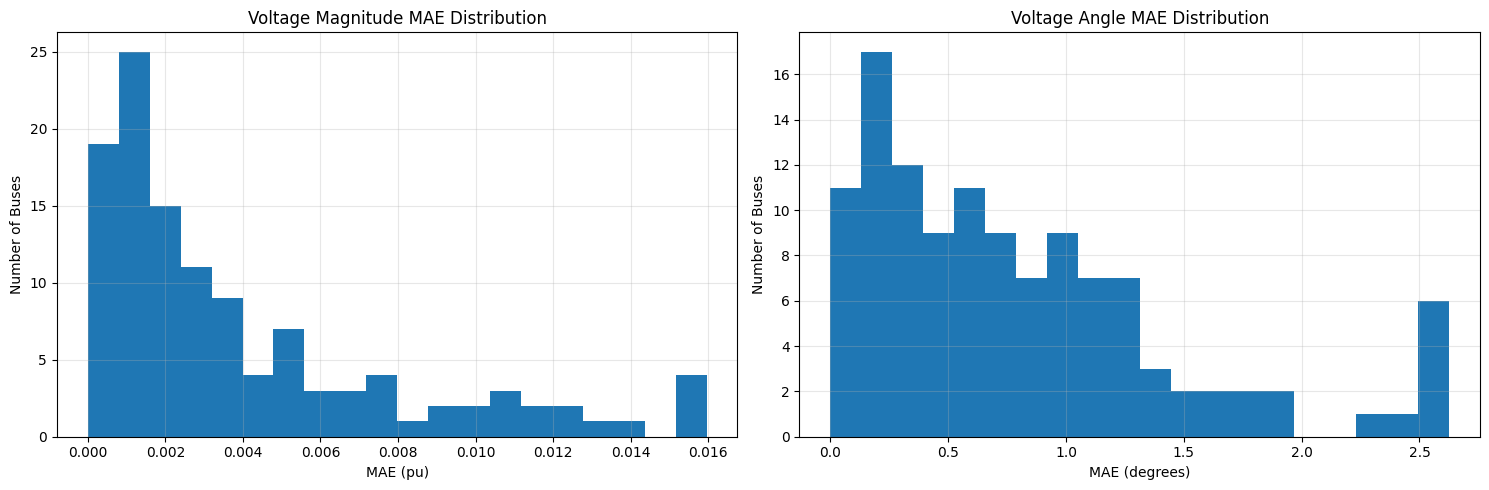

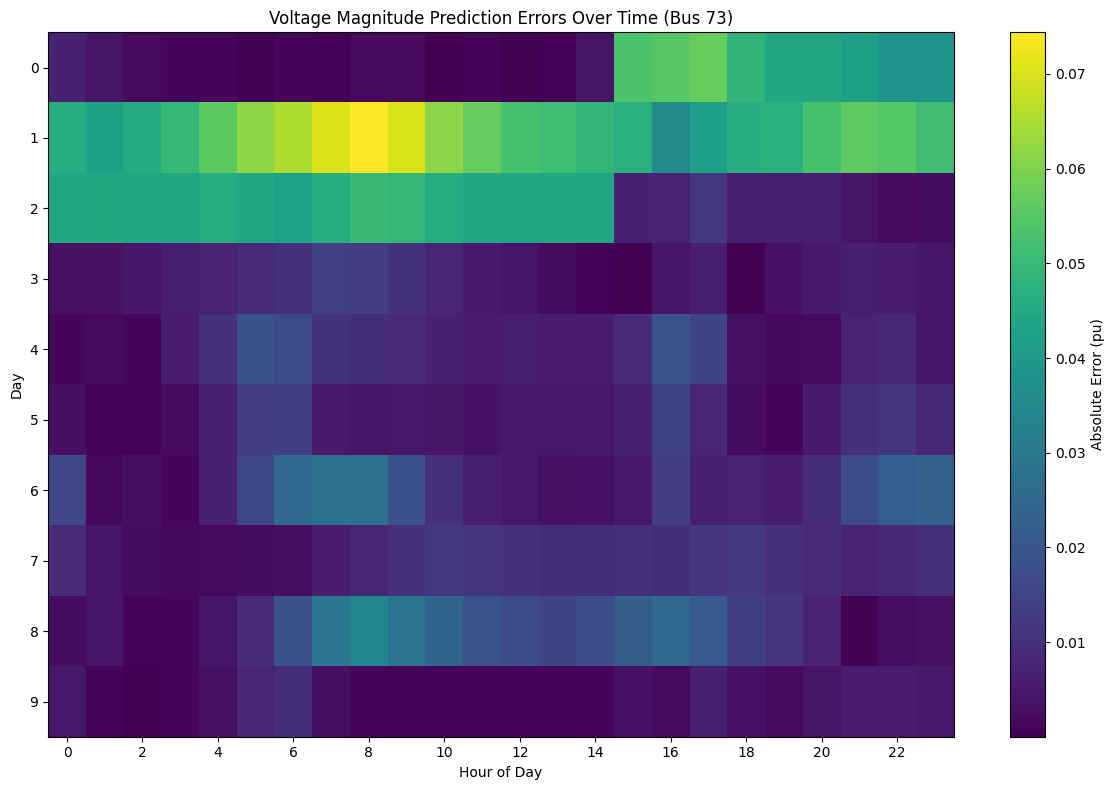


Saving results to ../results/day_ahead_model_results.pkl


In [10]:

# Load the builder object
print("Loading the builder object...")
builder_path = "../data/parsed/builder.pkl"

try:
    with open(builder_path, "rb") as f:
        builder = pickle.load(f)
    
    # Run the day-ahead model
    print("\nRunning day-ahead model...")
    results = run_day_ahead_model(builder, num_days=10, horizon=24, stride=24, plot_results=True)
    
    # Save the results
    results_dir = "../results"
    os.makedirs(results_dir, exist_ok=True)
    results_path = os.path.join(results_dir, "day_ahead_model_results.pkl")
    
    print(f"\nSaving results to {results_path}")
    with open(results_path, "wb") as f:
        pickle.dump(results, f)
    
except Exception as e:
    print(f"Error: {str(e)}")
    traceback.print_exc()

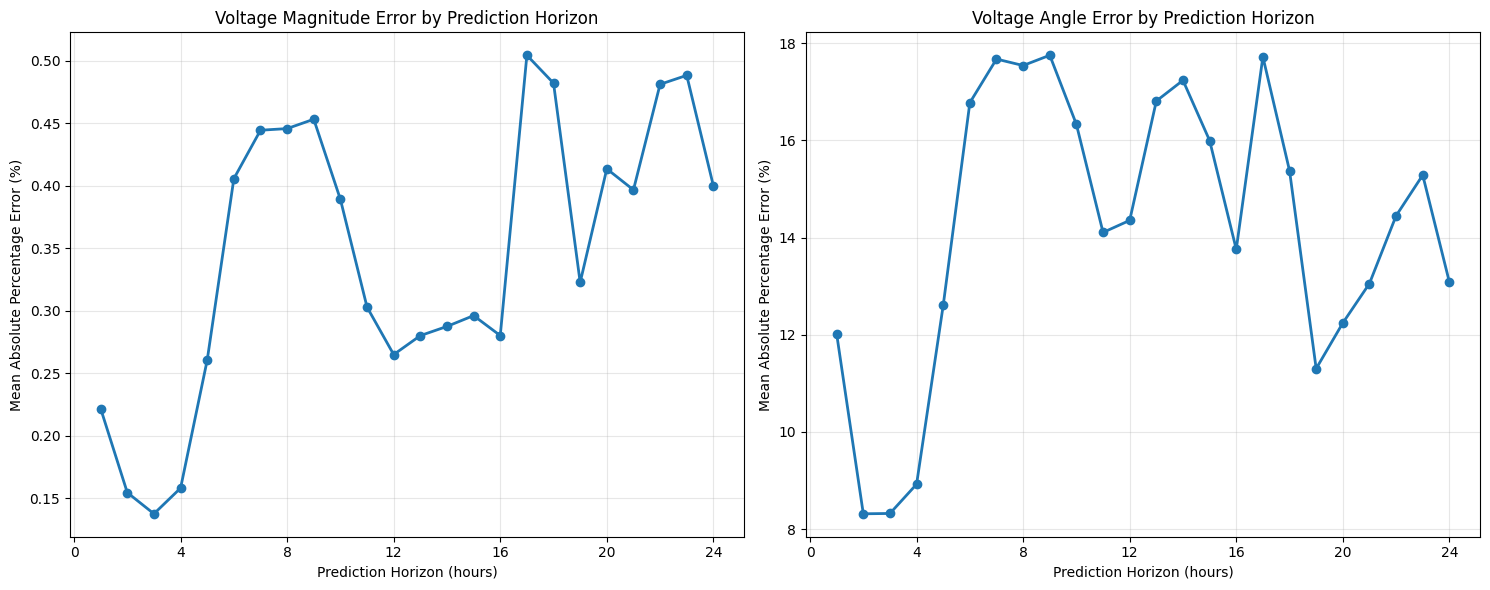

In [12]:
# Create a plot showing error vs prediction horizon (1-24 hours)
# First, extract necessary data from the results
prediction_points = results['prediction_points']
actual_vm = results['actual_vm']
actual_va = results['actual_va']
pred_vm = results['pred_vm']
pred_va = results['pred_va']
bus_ids = list(actual_vm.keys())
num_days = len(prediction_points) // 24

# Initialize lists to store errors by horizon
vm_errors_by_horizon = []
va_errors_by_horizon = []

# Calculate errors for each prediction horizon (1-24 hours)
for horizon in range(1, 25):  # 1 to 24 hours
    # For each horizon, collect errors across all buses
    vm_horizon_errors = []
    va_horizon_errors = []
    
    # Get the appropriate prediction points for this horizon
    for day in range(num_days):
        # The index in our prediction data for this day+horizon
        idx = day * 24 + (horizon - 1)
        
        if idx < len(prediction_points):
            # Collect errors for all buses at this horizon
            for bus_id in bus_ids:
                if idx < len(actual_vm[bus_id]):
                    # Calculate MAPE for voltage magnitude
                    actual = actual_vm[bus_id][idx]
                    pred = pred_vm[bus_id][idx]
                    # Avoid division by zero with small epsilon
                    if abs(actual) > 1e-6:
                        vm_pct_error = 100 * abs(actual - pred) / abs(actual)
                        vm_horizon_errors.append(vm_pct_error)
                    
                    # Calculate MAPE for voltage angle (handling zero angles)
                    actual = actual_va[bus_id][idx]
                    pred = pred_va[bus_id][idx]
                    # For angles, use MAE when close to zero
                    if abs(actual) > 1.0:  # threshold of 1 degree
                        va_pct_error = 100 * abs(actual - pred) / abs(actual)
                        va_horizon_errors.append(va_pct_error)
                    else:
                        # For small angles, use absolute error to avoid division issues
                        va_horizon_errors.append(abs(actual - pred))
    
    # Average the errors for this horizon
    if vm_horizon_errors:
        vm_errors_by_horizon.append(np.mean(vm_horizon_errors))
    else:
        vm_errors_by_horizon.append(0)
        
    if va_horizon_errors:
        va_errors_by_horizon.append(np.mean(va_horizon_errors))
    else:
        va_errors_by_horizon.append(0)

# Create the plot
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Voltage magnitude MAPE by horizon
axs[0].plot(range(1, 25), vm_errors_by_horizon, marker='o', linestyle='-', linewidth=2)
axs[0].set_title('Voltage Magnitude Error by Prediction Horizon')
axs[0].set_xlabel('Prediction Horizon (hours)')
axs[0].set_ylabel('Mean Absolute Percentage Error (%)')
axs[0].grid(True, alpha=0.3)
axs[0].set_xticks(range(0, 25, 4))

# Voltage angle MAPE by horizon
axs[1].plot(range(1, 25), va_errors_by_horizon, marker='o', linestyle='-', linewidth=2)
axs[1].set_title('Voltage Angle Error by Prediction Horizon')
axs[1].set_xlabel('Prediction Horizon (hours)')
axs[1].set_ylabel('Mean Absolute Percentage Error (%)')
axs[1].grid(True, alpha=0.3)
axs[1].set_xticks(range(0, 25, 4))

plt.tight_layout()
plt.show()

Processing 264 timesteps...
Making 169 forecasts...
Forecast 1/169: Training on hours 0-71, forecasting 72-95
Forecast 2/169: Training on hours 1-72, forecasting 73-96
Forecast 3/169: Training on hours 2-73, forecasting 74-97
Forecast 4/169: Training on hours 3-74, forecasting 75-98
Forecast 5/169: Training on hours 4-75, forecasting 76-99
Forecast 6/169: Training on hours 5-76, forecasting 77-100
Forecast 7/169: Training on hours 6-77, forecasting 78-101
Forecast 8/169: Training on hours 7-78, forecasting 79-102
Forecast 9/169: Training on hours 8-79, forecasting 80-103
Forecast 10/169: Training on hours 9-80, forecasting 81-104
Forecast 11/169: Training on hours 10-81, forecasting 82-105
Forecast 12/169: Training on hours 11-82, forecasting 83-106
Forecast 13/169: Training on hours 12-83, forecasting 84-107
Forecast 14/169: Training on hours 13-84, forecasting 85-108
Forecast 15/169: Training on hours 14-85, forecasting 86-109
Forecast 16/169: Training on hours 15-86, forecasting 87-

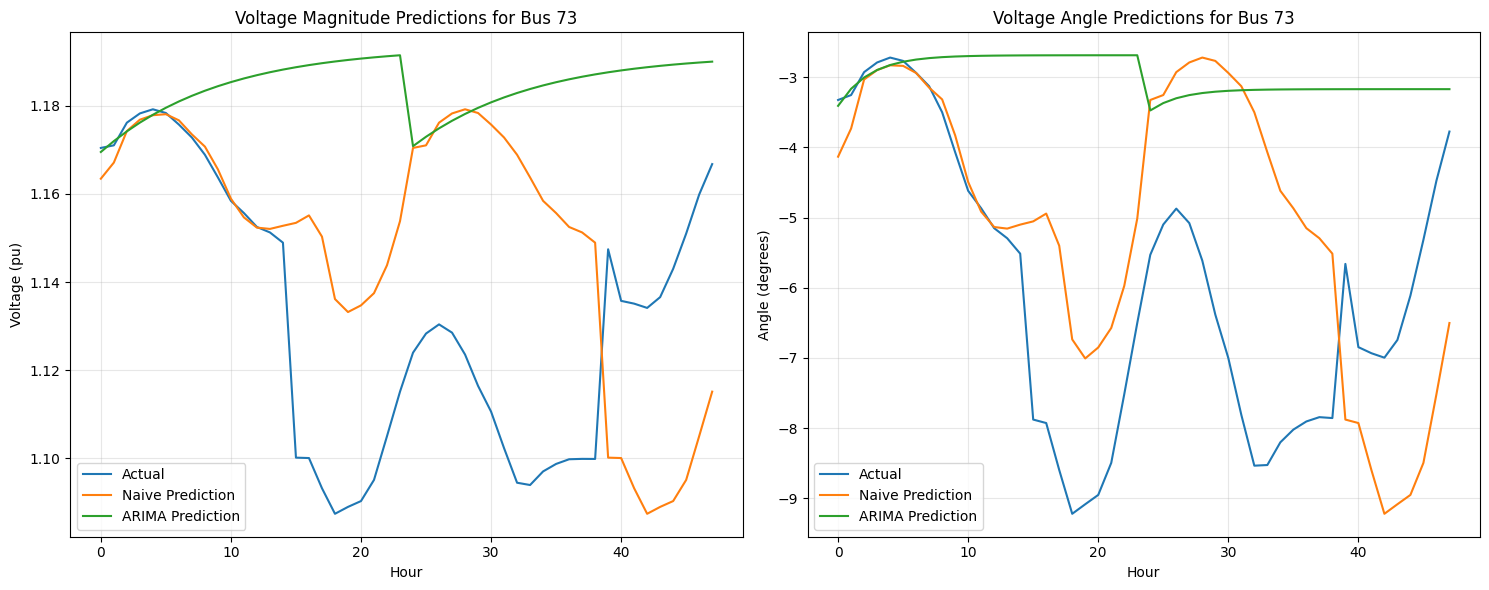

In [13]:
# Implement ARIMA model for time series forecasting
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')  # Suppress convergence warnings

def run_arima_model(builder, num_timesteps=264, forecast_horizon=24):
    """
    Implements ARIMA model for voltage prediction.
    """
    print(f"Processing {num_timesteps} timesteps...")
    all_timestep_data = []
    
    # Get all data points
    for t in range(num_timesteps):
        sample = builder.run(builder.timestamps[t])
        timestep_data = {}
        for bus_id, bus in sample.res_bus.iterrows():
            timestep_data[bus_id] = {
                'vm_pu': float(bus['vm_pu']),
                'va_degree': float(bus['va_degree'])
            }
        all_timestep_data.append(timestep_data)
    
    # Initialize dictionaries to store results
    bus_ids = list(all_timestep_data[0].keys())
    actual_vm = {bus_id: [] for bus_id in bus_ids}
    actual_va = {bus_id: [] for bus_id in bus_ids}
    pred_vm = {bus_id: [] for bus_id in bus_ids}
    pred_va = {bus_id: [] for bus_id in bus_ids}
    
    # Training window size (use 72 hours of historical data)
    train_size = 72
    
    # Ensure we have enough data
    if num_timesteps < train_size + forecast_horizon:
        print("Not enough data for training and forecasting")
        return None
    
    # Number of forecasts we can make
    num_forecasts = num_timesteps - train_size - forecast_horizon + 1
    
    print(f"Making {num_forecasts} forecasts...")
    
    # For each forecast point
    for i in range(num_forecasts):
        start_idx = i
        train_end_idx = start_idx + train_size
        
        print(f"Forecast {i+1}/{num_forecasts}: Training on hours {start_idx}-{train_end_idx-1}, forecasting {train_end_idx}-{train_end_idx+forecast_horizon-1}")
        
        # For each bus
        for bus_id in bus_ids:
            # Extract training data
            vm_train = [all_timestep_data[t][bus_id]['vm_pu'] for t in range(start_idx, train_end_idx)]
            va_train = [all_timestep_data[t][bus_id]['va_degree'] for t in range(start_idx, train_end_idx)]
            
            # Actual values to compare with predictions
            for h in range(forecast_horizon):
                forecast_idx = train_end_idx + h
                actual_vm[bus_id].append(all_timestep_data[forecast_idx][bus_id]['vm_pu'])
                actual_va[bus_id].append(all_timestep_data[forecast_idx][bus_id]['va_degree'])
            
            # Fit ARIMA model for voltage magnitude (using auto ARIMA parameters)
            try:
                # For simplicity, use fixed parameters (1,1,1) - in practice, you'd use auto ARIMA
                vm_model = ARIMA(vm_train, order=(1, 1, 1))
                vm_fit = vm_model.fit()
                vm_forecast = vm_fit.forecast(steps=forecast_horizon)
                
                va_model = ARIMA(va_train, order=(1, 1, 1))
                va_fit = va_model.fit()
                va_forecast = va_fit.forecast(steps=forecast_horizon)
                
                # Store predictions
                pred_vm[bus_id].extend(vm_forecast)
                pred_va[bus_id].extend(va_forecast)
            except:
                # If ARIMA fails, fall back to naive method (use last observed value)
                last_vm = vm_train[-1]
                last_va = va_train[-1]
                pred_vm[bus_id].extend([last_vm] * forecast_horizon)
                pred_va[bus_id].extend([last_va] * forecast_horizon)
    
    # Calculate errors
    vm_mae_per_bus = {}
    va_mae_per_bus = {}
    
    for bus_id in bus_ids:
        vm_mae_per_bus[bus_id] = mean_absolute_error(actual_vm[bus_id], pred_vm[bus_id])
        va_mae_per_bus[bus_id] = mean_absolute_error(actual_va[bus_id], pred_va[bus_id])
    
    # Overall metrics
    avg_vm_mae = np.mean(list(vm_mae_per_bus.values()))
    avg_va_mae = np.mean(list(va_mae_per_bus.values()))
    
    print("\nARIMA Model Results:")
    print(f"Average Voltage Magnitude MAE: {avg_vm_mae:.6f} pu")
    print(f"Average Voltage Angle MAE: {avg_va_mae:.6f} degrees")
    
    return {
        'actual_vm': actual_vm,
        'actual_va': actual_va,
        'pred_vm': pred_vm,
        'pred_va': pred_va,
        'vm_mae_per_bus': vm_mae_per_bus,
        'va_mae_per_bus': va_mae_per_bus,
        'avg_vm_mae': avg_vm_mae,
        'avg_va_mae': avg_va_mae
    }

# Run the ARIMA model
arima_results = run_arima_model(builder, num_timesteps=264, forecast_horizon=24)

# Compare with naive model
print("\nModel Comparison:")
print("Naive Model:")
print(f"  Voltage Magnitude MAE: {results['avg_vm_mae']:.6f} pu")
print(f"  Voltage Angle MAE: {results['avg_va_mae']:.6f} degrees")
print("ARIMA Model:")
print(f"  Voltage Magnitude MAE: {arima_results['avg_vm_mae']:.6f} pu")
print(f"  Voltage Angle MAE: {arima_results['avg_va_mae']:.6f} degrees")

# Plot comparison for a selected bus
worst_vm_bus = results['worst_vm_bus']

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(actual_vm[worst_vm_bus][:48], label='Actual')
plt.plot(pred_vm[worst_vm_bus][:48], label='Naive Prediction')
plt.plot(arima_results['pred_vm'][worst_vm_bus][:48], label='ARIMA Prediction')
plt.title(f'Voltage Magnitude Predictions for Bus {worst_vm_bus}')
plt.xlabel('Hour')
plt.ylabel('Voltage (pu)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(actual_va[worst_vm_bus][:48], label='Actual')
plt.plot(pred_va[worst_vm_bus][:48], label='Naive Prediction')
plt.plot(arima_results['pred_va'][worst_vm_bus][:48], label='ARIMA Prediction')
plt.title(f'Voltage Angle Predictions for Bus {worst_vm_bus}')
plt.xlabel('Hour')
plt.ylabel('Angle (degrees)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
sample

This pandapower network includes the following parameter tables:
   - bus (118 elements)
   - load (91 elements)
   - gen (321 elements)
   - ext_grid (1 element)
   - line (177 elements)
   - trafo (9 elements)
   - bus_geodata (118 elements)
 and the following results tables:
   - res_bus (118 elements)
   - res_line (177 elements)
   - res_trafo (9 elements)
   - res_ext_grid (1 element)
   - res_load (91 elements)
   - res_gen (321 elements)

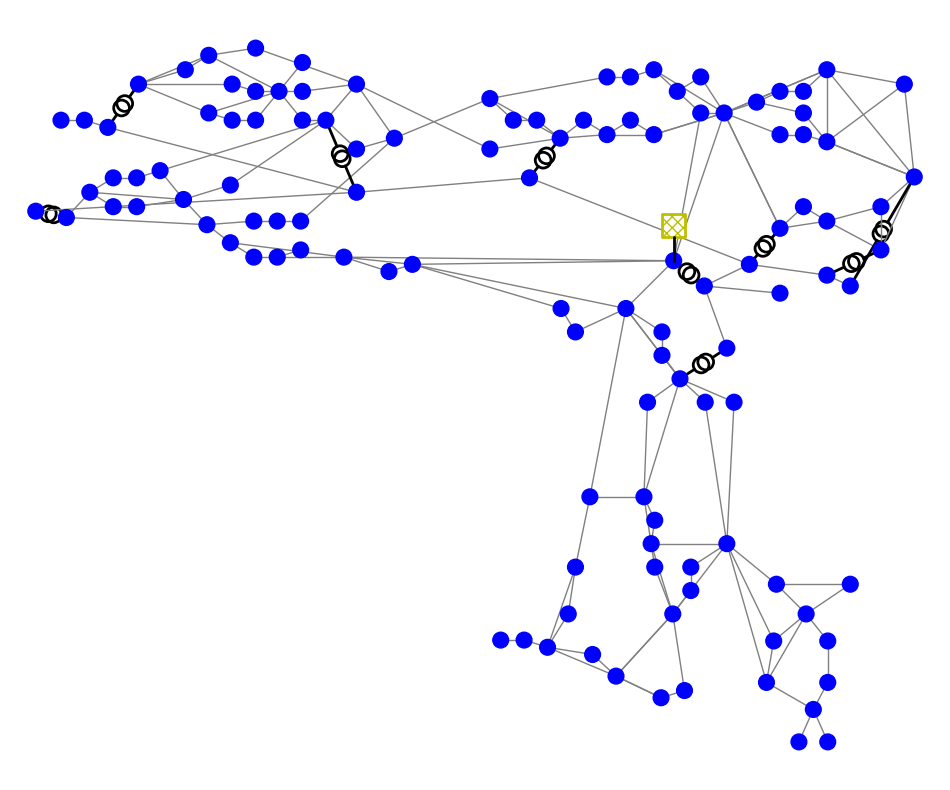

Text(0.5, 1.0, 'NREL 118-Bus System One-line Diagram')

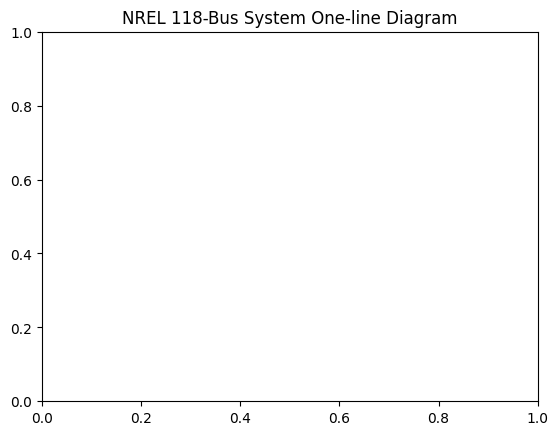

In [16]:
# Example for creating one-line diagram
import pandapower.plotting as plot
import matplotlib.pyplot as plt

# Create plot with pandapower
fig, ax = plt.subplots(figsize=(12, 10))
plot.simple_plot(sample, ax=ax)  # sample is a pandapower network
plt.title("NREL 118-Bus System One-line Diagram")